<a href="https://colab.research.google.com/github/xc308/Understanding-Transformer-Attention-Weights/blob/main/Compute_Attention_Weights_from_Pre_trained_Projection_Matrices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compute Attention Weights from Learned Projection Matrices

In [1]:
!pip install orbax-checkpoint==0.11.21
!pip install "git+https://github.com/google-deepmind/ai-foundations.git@main"

import jax # For working with vectors and matrices.
import jax.numpy as jnp # For working with vectors and matrices.
from ai_foundations import generation # For prompting the Gemma model.
from ai_foundations import visualizations # For visualizing attention weights.
from ai_foundations import attention # For working with Q,K,V matrices.
# For providing feedback on implementation.
from ai_foundations.feedback.course_4 import attention as attention_feedback

  Cloning https://github.com/google-deepmind/ai-foundations.git (to revision main) to /tmp/pip-req-build-m0i5i7i4
  Running command git clone --filter=blob:none --quiet https://github.com/google-deepmind/ai-foundations.git /tmp/pip-req-build-m0i5i7i4
  Resolved https://github.com/google-deepmind/ai-foundations.git to commit 524d6114bbce631dafc00ba3496607a0bc60c804
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# Initialize caches for prompts.
previous_prompt = None
previous_prompt2 = None

# Load special version of the Gemma-1B model that provides access to attention
# weights and QKV matrices.
print("Loading Gemma-1B...")
model = generation.load_gemma("Gemma-1B-AttentionWeight")
print("Loaded Gemma-1B.")

Loading Gemma-1B...
Loaded Gemma-1B.


Generated text: Jide was hungry so she went looking for food


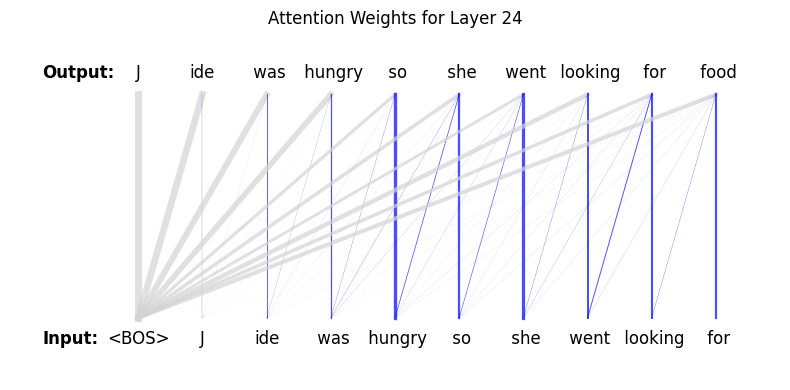

In [3]:
# @title Visualize attention weights (reference implementation)
layer = 24  # @param {type:"slider", min: 0, max: 25}

prompt = "Jide was hungry so she went looking for"  # @param {type: "string"}
# @markdown Check the following box to display the attention weights for all tokens, not just for the generated one:
show_all_weights = True  # @param {type:"boolean"}


if prompt != previous_prompt:
  (
      output_text,
      _,
      tokenizer,
      attention_weights,
      _,
      qkv_dict,
  ) = generation.prompt_attention_transformer_model(
      prompt, model, sampling_mode="greedy"
  )
  tokens = [tokenizer.tokens[t] for t in tokenizer.encode(output_text)]
  previous_prompt = prompt

print(f"Generated text: {output_text}")

visualizations.visualize_attention(
    tokens,
    attention_weights[f"layer_{layer}"],
    layer,
    min_line_thickness=0,
    max_line_thickness=5,
    show_all_weights=show_all_weights,
)

In [4]:
def compute_attention(
    qkv_dict: dict[str, dict[str, jax.Array]], layer: int
) -> tuple[jax.Array, jax.Array, jax.Array]:
  """Computes the attention weights for a layer.

  Args:
    qkv_dict: A dictionary containing the raw query, key, and value
      projections for all layers. The keys are strings identifying the layers
      and matrix types, and values are the corresponding JAX arrays.
    layer: The specific layer for which to compute the attention weights.

  Returns:
    Y: The output of the attention layer. Shape: (n_tokens, embedding_dim).
    alpha: The attention weights. Shape: (n_tokens, n_tokens).
    logits: The raw logits used to compute the attention weights.
      Shape: (n_tokens, n_tokens).
  """
  # Extract the query, key, and value projection matrices from `qkv_dict`.
  query_proj, key_proj, value_proj = attention.get_qkv_matrices(qkv_dict, layer)

  d_k = key_proj.shape[-1]
  logits = query_proj @ key_proj.T / jnp.sqrt(d_k)  # @ is summing over embed_dim

  alpha = jax.nn.softmax(logits, axis = -1)  # n_token by n_token; softmax normalise across all cols for a token i (a row), so each row sums to 1

  Y = alpha @ value_proj  # Compute the output here.

  return Y, alpha, logits

Generated text: Jide was hungry so she went looking for food


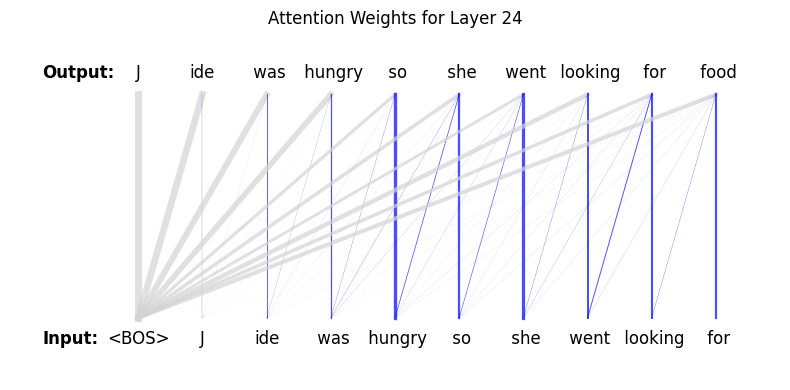

In [6]:
# @title Visualize attention weights (your implementation)
layer = 24  # @param {type:"slider", min: 0, max: 25}

prompt = "Jide was hungry so she went looking for"  # @param {type: 'string'}

# @markdown Check the following box to display the attention weights for all tokens, not just for the generated one:
show_all_weights = True  # @param {type:"boolean", label: "sfdsf"}

model_name = "Gemma-1B"

if prompt != previous_prompt2:
  (
      output_text2,
      _,
      tokenizer,
      attention_weights2,
      attention_mask2,
      qkv_dict2,
  ) = generation.prompt_attention_transformer_model(
      prompt, model, sampling_mode="greedy"
  )
  tokens2 = [tokenizer.tokens[t] for t in tokenizer.encode(output_text2)]
  previous_prompt2 = prompt

print(f"Generated text: {output_text2}")


attn_out, attn_weights, attn_logits = compute_attention(qkv_dict2, layer)
# Post-process attention weights to apply masking (to be covered in subsequent
# activities), so that the attention weights are idential to the ones computed
# by Gemma.
attn_weights_post_processed = attention.post_process_attention(
    attn_logits, attention_mask2
)

visualizations.visualize_attention(
    tokens2,
    attn_weights_post_processed,
    layer,
    min_line_thickness=0,
    max_line_thickness=5,
    show_all_weights=show_all_weights,
)